# Intro Graph Neural Network (GNNs)

In [34]:
import networkx as nx
import matplotlib.pyplot as plt

In [35]:
H = nx.DiGraph()

In [36]:
H.add_nodes_from([
  (0, {"color": "blue", "size": 250}),

  (1, {"color": "yellow", "size": 400}),

  (2, {"color": "orange", "size": 150}),

  (3, {"color": "red", "size": 600})


])

H.add_edges_from([
  (0, 1),

  (1, 2),

  (1, 0),

  (1, 3),

  (2, 3),

  (3,0)


])

In [37]:
node_colors = nx.get_node_attributes(H, "color").values()
colors = list(node_colors)
node_sizes = nx.get_node_attributes(H, "size").values()
sizes = list(node_sizes)

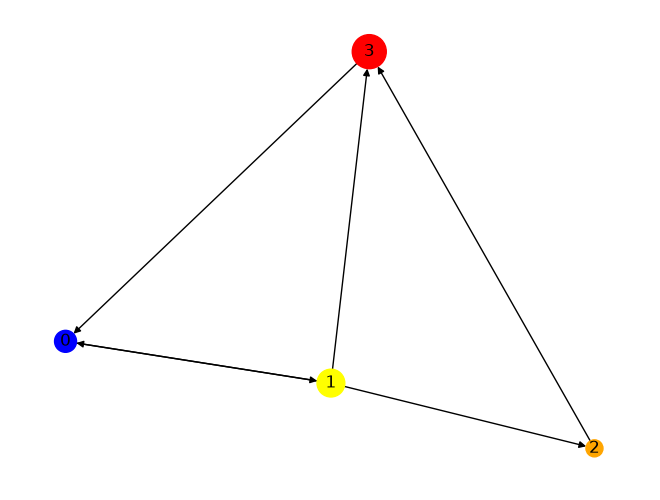

In [38]:
nx.draw(H, with_labels=True, node_color=colors, node_size=sizes)

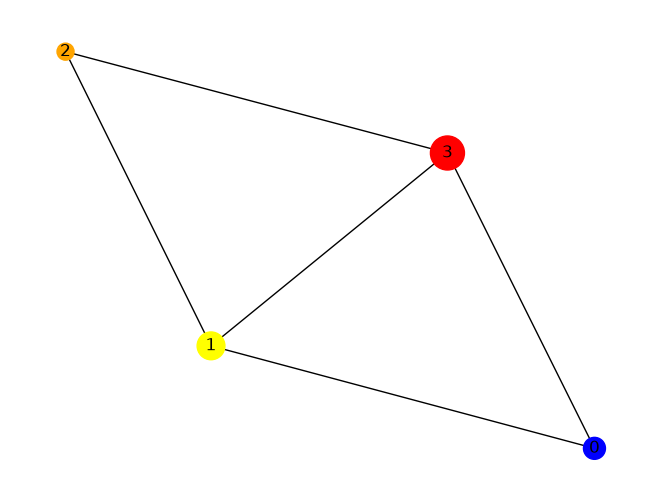

In [39]:
G = H.to_undirected()
nx.draw(G, with_labels=True, node_color=colors, node_size=sizes)

# PyGeometric

In [40]:
# !pip install torch # install sekali aja habis itu komen lagi

In [41]:
%%capture
import os
import torch
# os.environ['TORCH'] = torch.__version__ # run kalo diperluin aja
os.environ['PYTHONWARNINGS'] = "ignore" # ignore semua warning :D
# !pip install torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
# !pip install torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
# !pip install git+https://github.com/pyg-team/pytorch_geometric.git

In [42]:
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures

In [43]:
dataset = Planetoid(root='data/Planetoid', name='Cora', transform=NormalizeFeatures())

print(f'Dataset: {dataset}:')
print('======================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

data = dataset[0]
print(data)

Dataset: Cora():
Number of graphs: 1
Number of features: 1433
Number of classes: 7
Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


> Cora Data ini ternyata berisi 2708 nodes, 10566 edges, 1433 features, dan 7 class

### Klasifikasi Node dengan GNN

Jadi disini dibuat struktur model GCN (Graph Convolutional Network) yang berisi 2 GCNConv layer dengan aktivasi relu dan juga dropout rate 0.5, dengan modelnya berisi 16 channel
**GCN Layer:**
$$
x_v^{(l+1)} = W^{(l+1)} \sum_{w \in N(v) \cup \{v\}} \frac{1}{c_{w,v}} \, x_w^{(l)}
$$

| Simbol | Arti |
|:---|:---|
| $v$ | Node target yang sedang diperbarui representasinya. |
| $w$ | Node tetangga dari $v$ yang ikut diagregasi. |
| $N(v)$ | Himpunan tetangga langsung dari $v$ (tanpa self-loop). |
| $\\{v\\}$ | Node $v$ itu sendiri. |
| $N(v) \cup \\{v\\}$ | Tetangga $v$ **plus** $v$ sendiri → disebut **self-loop**. |
| $l$ | Indeks layer. $l=0$ berarti fitur input awal. |
| $x_v^{(l)}$ | Vektor fitur / hidden state node $v$ pada layer $l$. |
| $x_v^{(l+1)}$ | Vektor fitur baru node $v$ setelah agregasi dan transformasi. |
| $x_w^{(l)}$ | Vektor fitur node tetangga $w$ pada layer $l$. |
| $W^{(l+1)}$ | Matriks bobot **learnable** untuk layer ke-$(l+1)$. Ukuran $d_{\text{out}} \times d_{\text{in}}$. |
| $c_{w,v}$ | Koefisien normalisasi untuk pasangan $(w,v)$. Biasanya $c_{w,v} = \sqrt{\deg(w)\deg(v)}$. |
| $1/c_{w,v}$ | Faktor normalisasi agar node berderajat tinggi tidak mendominasi. |
| $\sum$ | Operasi agregasi (penjumlahan) yang **permutation-invariant**. |
| $\sigma(\cdot)$ | Fungsi aktivasi non-linear (ReLU, dll). Belum tertulis di rumus. |


### Apa yang Sebenarnya Terjadi?

Langkah demi langkah:

1. **Kumpulkan pesan** dari semua tetangga $w \in N(v)$ dan dari $v$ sendiri.
2. **Normalisasi** tiap pesan dengan $1/c_{w,v}$.
3. **Jumlahkan** semua pesan yang sudah dinormalisasi.
4. **Transformasi linear** dengan matriks bobot $W^{(l+1)}$.
5. (Biasanya) **Aktivasi** dengan $\sigma$, misalnya ReLU.

Rumus lengkapnya lebih tepat ditulis:

$$
x_v^{(l+1)} = \sigma\left( W^{(l+1)} \sum_{w \in N(v) \cup \{v\}} \frac{1}{c_{w,v}} \, x_w^{(l)} \right)
$$


### Kaitannya dengan Klasifikasi Node

Alur klasifikasi node:

1. **Input**: fitur awal $x_v^{(0)}$ untuk setiap node $v$.
2. **Message passing** selama $L$ layer → embedding akhir $x_v^{(L)}$.
3. **Classifier**: layer linear + softmax.

$$
\hat{y}_v = \mathrm{softmax}(W_{\text{out}} \, x_v^{(L)} + b)
$$

4. **Prediksi**: $\arg\max_k \hat{y}_{v,k}$ → kelas node $v$.

Variabel tambahan untuk klasifikasi:

| Simbol | Arti |
|:---|:---|
| $\hat{y}_v$ | Vektor probabilitas kelas untuk node $v$. |
| $C$ | Jumlah kelas. |
| $W_{\text{out}}$ | Matriks bobot layer output. |
| $b$ | Bias layer output. |
| $\mathcal{L}$ | Loss, biasanya cross-entropy. |

### Bentuk Matriks (Gambaran Global)

Jika semua node ditulis sekaligus:

$$
X^{(l+1)} = \sigma\left( \hat{D}^{-1/2} \hat{A} \hat{D}^{-1/2} X^{(l)} W^{(l+1)\top} \right)
$$

dengan:

- $\hat{A} = A + I$ → matriks adjacency plus self-loop.
- $\hat{D}$ → matriks derajat dari $\hat{A}$.
- $X^{(l)}$ → matriks fitur semua node pada layer $l$.

Bentuk ini ekuivalen dengan rumus per-node, hanya ditulis secara global.

In [44]:
from torch_geometric.nn import GCNConv
import torch.nn.functional as F

class GCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        torch.manual_seed(1234567)
        self.conv1 = GCNConv(dataset.num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model = GCN(hidden_channels=16)
print(model)

GCN(
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
)


## Visualisasi GCN network yang belum dilatih

In [45]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

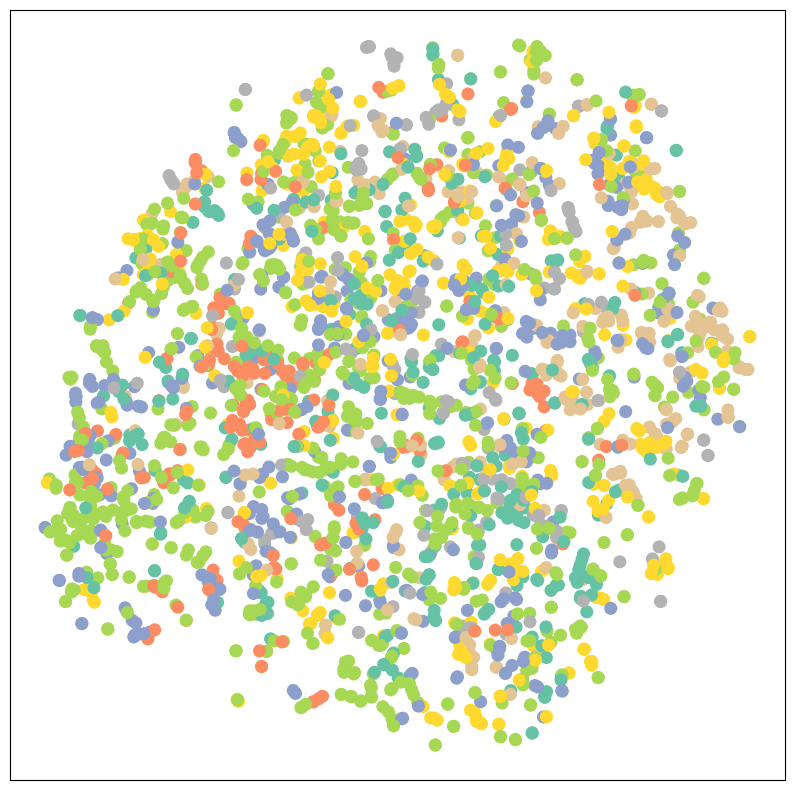

In [46]:
model.eval()

out = model(data.x, data.edge_index)
visualize(out, color=data.y)